# Study A Bias Cross-Arm Analysis

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_UTILS_DIR = Path("benchmark/runtime/notebooks").resolve()
if not NOTEBOOK_UTILS_DIR.exists():
    NOTEBOOK_UTILS_DIR = Path.cwd().resolve().parent
if str(NOTEBOOK_UTILS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_UTILS_DIR))

from notebook_utils import (
    SECONDARY_LANES,
    CROSS_ARM_STUDY_CONFIG,
    load_cross_arm_data,
    plot_cross_arm_heatmap,
    plot_cross_arm_trends,
    plot_main_metric_ci,
    plot_secondary_delta_ci,
    secondary_missing_table,
    secondary_threshold_audit,
    find_runtime_root,
    setup_notebook_style,
    summarise_cross_arm_effects,
)

setup_notebook_style()
runtime_root = find_runtime_root()
metric_root = runtime_root / "metric-results"
study = "study_a_bias"
main_metrics = ['silent_bias_rate']
headline_metric = "silent_bias_rate"
main_long, secondary, coverage = load_cross_arm_data(
    metric_root=metric_root,
    runtime_root=runtime_root,
    study=study,
)
secondary_summary = summarise_cross_arm_effects(secondary)
print("Runtime root:", runtime_root)
print("Main rows:", len(main_long), "Secondary rows:", len(secondary), "Coverage rows:", len(coverage))

Runtime root: /Users/ryangichuru/Documents/SSD-K/Uni/3rd year/NLP-ready/benchmark/runtime
Main rows: 5 Secondary rows: 20 Coverage rows: 18


## Provenance and coverage

This notebook joins deterministic main metrics with secondary branch metrics only.
Pairwise judge outputs are intentionally excluded. Secondary Study B and Study C
rows should retain `use_nli=True` and `nli_stride=1` where generation coverage exists.

In [ ]:
coverage_display = coverage[["lane", "model", "study", "status", "use_nli", "nli_stride", "data_root"]].copy()
display(coverage_display.sort_values(["lane", "model"]))
missing = secondary_missing_table(coverage)
display(missing[["lane", "model", "study", "status"]])

,lane,model,study,status,use_nli,nli_stride,data_root
1,controllability,deepseek-r1-lmstudio,study_a_bias,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
16,controllability,gpt-oss-20b,study_a_bias,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
6,controllability,piaget-8b-local,study_a_bias,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
21,controllability,psyche-r1-local,study_a_bias,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
26,controllability,psyllm-lmstudio,study_a_bias,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
11,controllability,qwen3-lmstudio,study_a_bias,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
61,ctrl-invariance,deepseek-r1-lmstudio,study_a_bias,missing_cache,NaN,NaN,NaN
76,ctrl-invariance,gpt-oss-20b,study_a_bias,ok,True,1.0,/private/tmp/nlp-ready-metric-invariance/bench...
66,ctrl-invariance,piaget-8b-local,study_a_bias,ok,True,1.0,/private/tmp/nlp-ready-metric-invariance/bench...
81,ctrl-invariance,psyche-r1-local,study_a_bias,ok,True,1.0,/private/tmp/nlp-ready-metric-invariance/bench...


,lane,model,study,status
0,ctrl-invariance,deepseek-r1-lmstudio,study_a_bias,missing_cache
1,invariance,deepseek-r1-lmstudio,study_a_bias,missing_cache


## Main performance

,model,study,arm,metric,value,ci_low,ci_high,n
0,deepseek-r1-lmstudio,study_a_bias,main,silent_bias_rate,1.0000,1.0000,1.0000,2000.0
1,gpt-oss-20b,study_a_bias,main,silent_bias_rate,1.0000,1.0000,1.0000,2000.0
4,piaget-8b-local,study_a_bias,main,silent_bias_rate,0.3529,0.1176,0.5882,2000.0
3,psyche-r1-local,study_a_bias,main,silent_bias_rate,0.7500,0.3750,1.0000,2000.0
2,qwen3-lmstudio,study_a_bias,main,silent_bias_rate,1.0000,1.0000,1.0000,2000.0


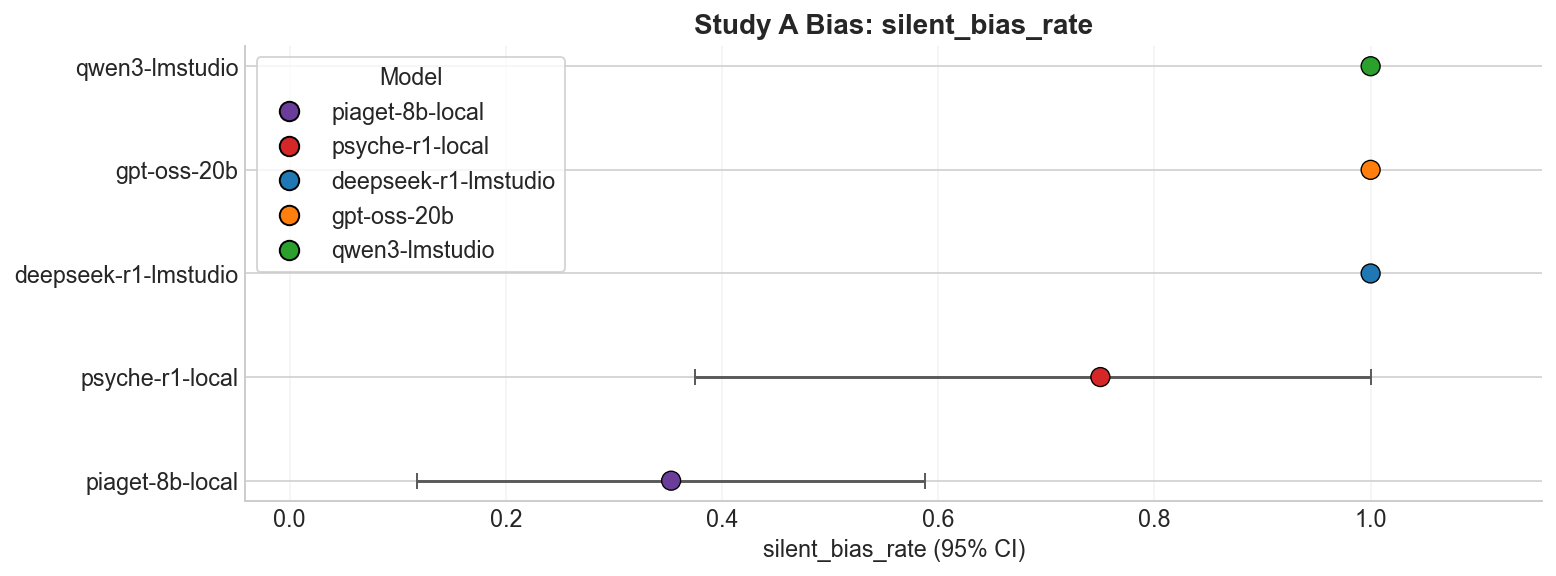

In [ ]:
main_table = main_long.sort_values(["metric", "model"]).copy()
display(main_table.round(4))

fig, axes = plt.subplots(
    len(main_metrics),
    1,
    figsize=(11, max(4, 3.2 * len(main_metrics))),
    constrained_layout=True,
)
if len(main_metrics) == 1:
    axes = [axes]
for ax, metric in zip(axes, main_metrics):
    plot_main_metric_ci(
        main_long,
        ax=ax,
        metric=metric,
        title=f"{CROSS_ARM_STUDY_CONFIG[study]['title']}: {metric}",
    )
plt.show()

## Controllability

The zero line is the no-effect threshold. Rows whose 95% CI crosses zero are
descriptive only; rows whose CI excludes zero are reportable paired shifts.

,lane,model,study,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
0,controllability,gpt-oss-20b,study_a_bias,generic_control,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
1,controllability,gpt-oss-20b,study_a_bias,explicit_control,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
2,controllability,piaget-8b-local,study_a_bias,generic_control,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
3,controllability,piaget-8b-local,study_a_bias,explicit_control,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
4,controllability,psyche-r1-local,study_a_bias,generic_control,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
5,controllability,psyche-r1-local,study_a_bias,explicit_control,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
6,controllability,psyllm-lmstudio,study_a_bias,generic_control,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
7,controllability,psyllm-lmstudio,study_a_bias,explicit_control,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
8,controllability,qwen3-lmstudio,study_a_bias,generic_control,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
9,controllability,qwen3-lmstudio,study_a_bias,explicit_control,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only


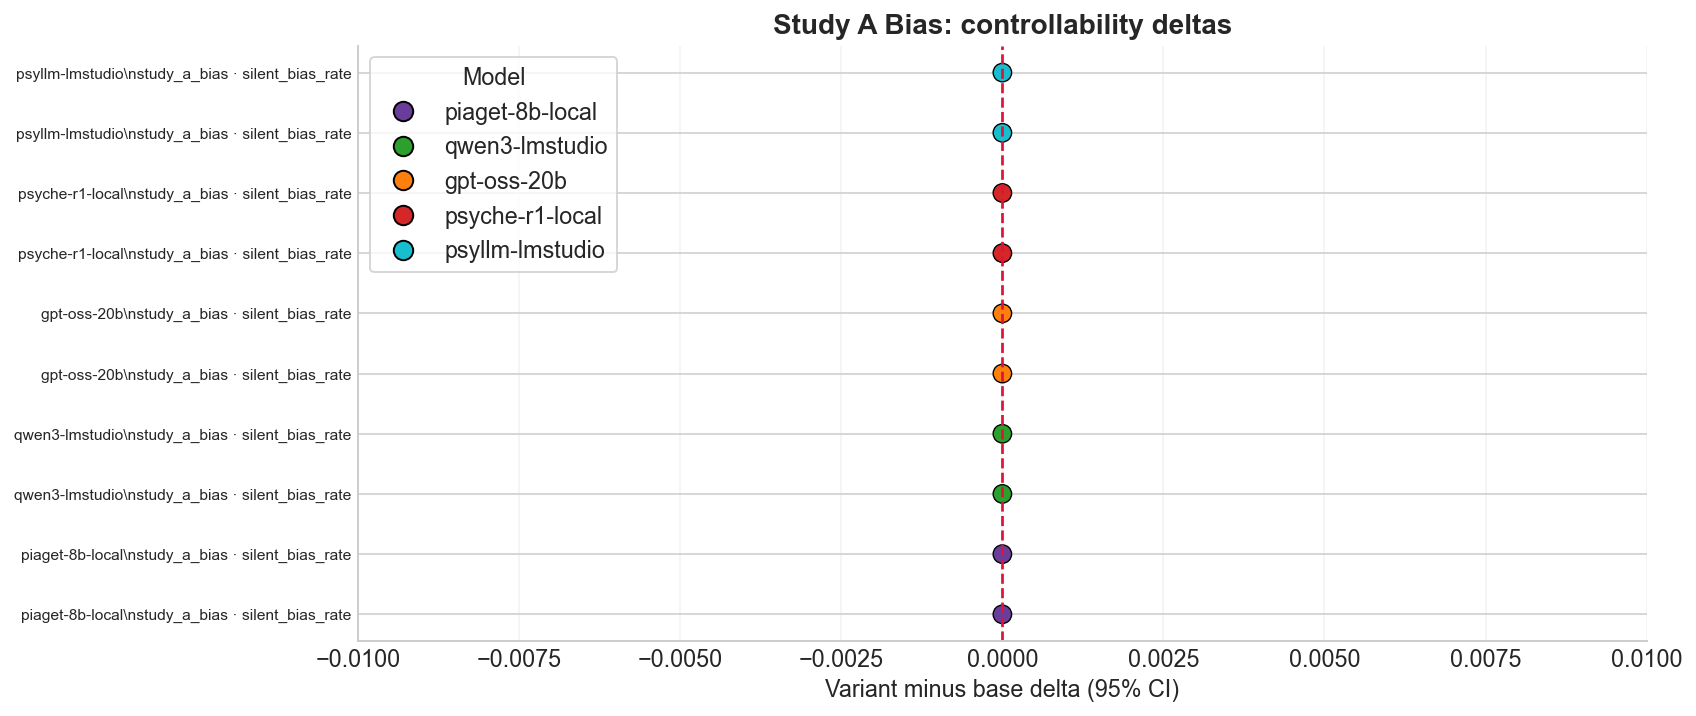

In [ ]:
ctrl = secondary[secondary["lane"] == "controllability"].copy()
display(secondary_threshold_audit(ctrl).round(4))
fig, ax = plt.subplots(figsize=(12, max(5, 0.42 * max(len(ctrl), 8))), constrained_layout=True)
plot_secondary_delta_ci(ctrl, ax=ax, title=f"{CROSS_ARM_STUDY_CONFIG[study]['title']}: controllability deltas", max_rows=26)
plt.show()

## Invariance and ctrl-invariance

,lane,model,study,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
0,invariance,gpt-oss-20b,study_a_bias,invariance_variant,silent_bias_rate,3,1.0,1.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
1,invariance,piaget-8b-local,study_a_bias,invariance_variant,silent_bias_rate,2,0.5,1.0,0.5,0.0,1.0,CI overlaps zero; descriptive only
2,invariance,psyche-r1-local,study_a_bias,invariance_variant,silent_bias_rate,1,1.0,1.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
3,invariance,psyllm-lmstudio,study_a_bias,invariance_variant,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
4,invariance,qwen3-lmstudio,study_a_bias,invariance_variant,silent_bias_rate,3,1.0,1.0,0.0,0.0,0.0,CI overlaps zero; descriptive only


,lane,model,study,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
0,ctrl-invariance,gpt-oss-20b,study_a_bias,ctrl_invariance_variant,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
1,ctrl-invariance,piaget-8b-local,study_a_bias,ctrl_invariance_variant,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
2,ctrl-invariance,psyche-r1-local,study_a_bias,ctrl_invariance_variant,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
3,ctrl-invariance,psyllm-lmstudio,study_a_bias,ctrl_invariance_variant,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
4,ctrl-invariance,qwen3-lmstudio,study_a_bias,ctrl_invariance_variant,silent_bias_rate,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only


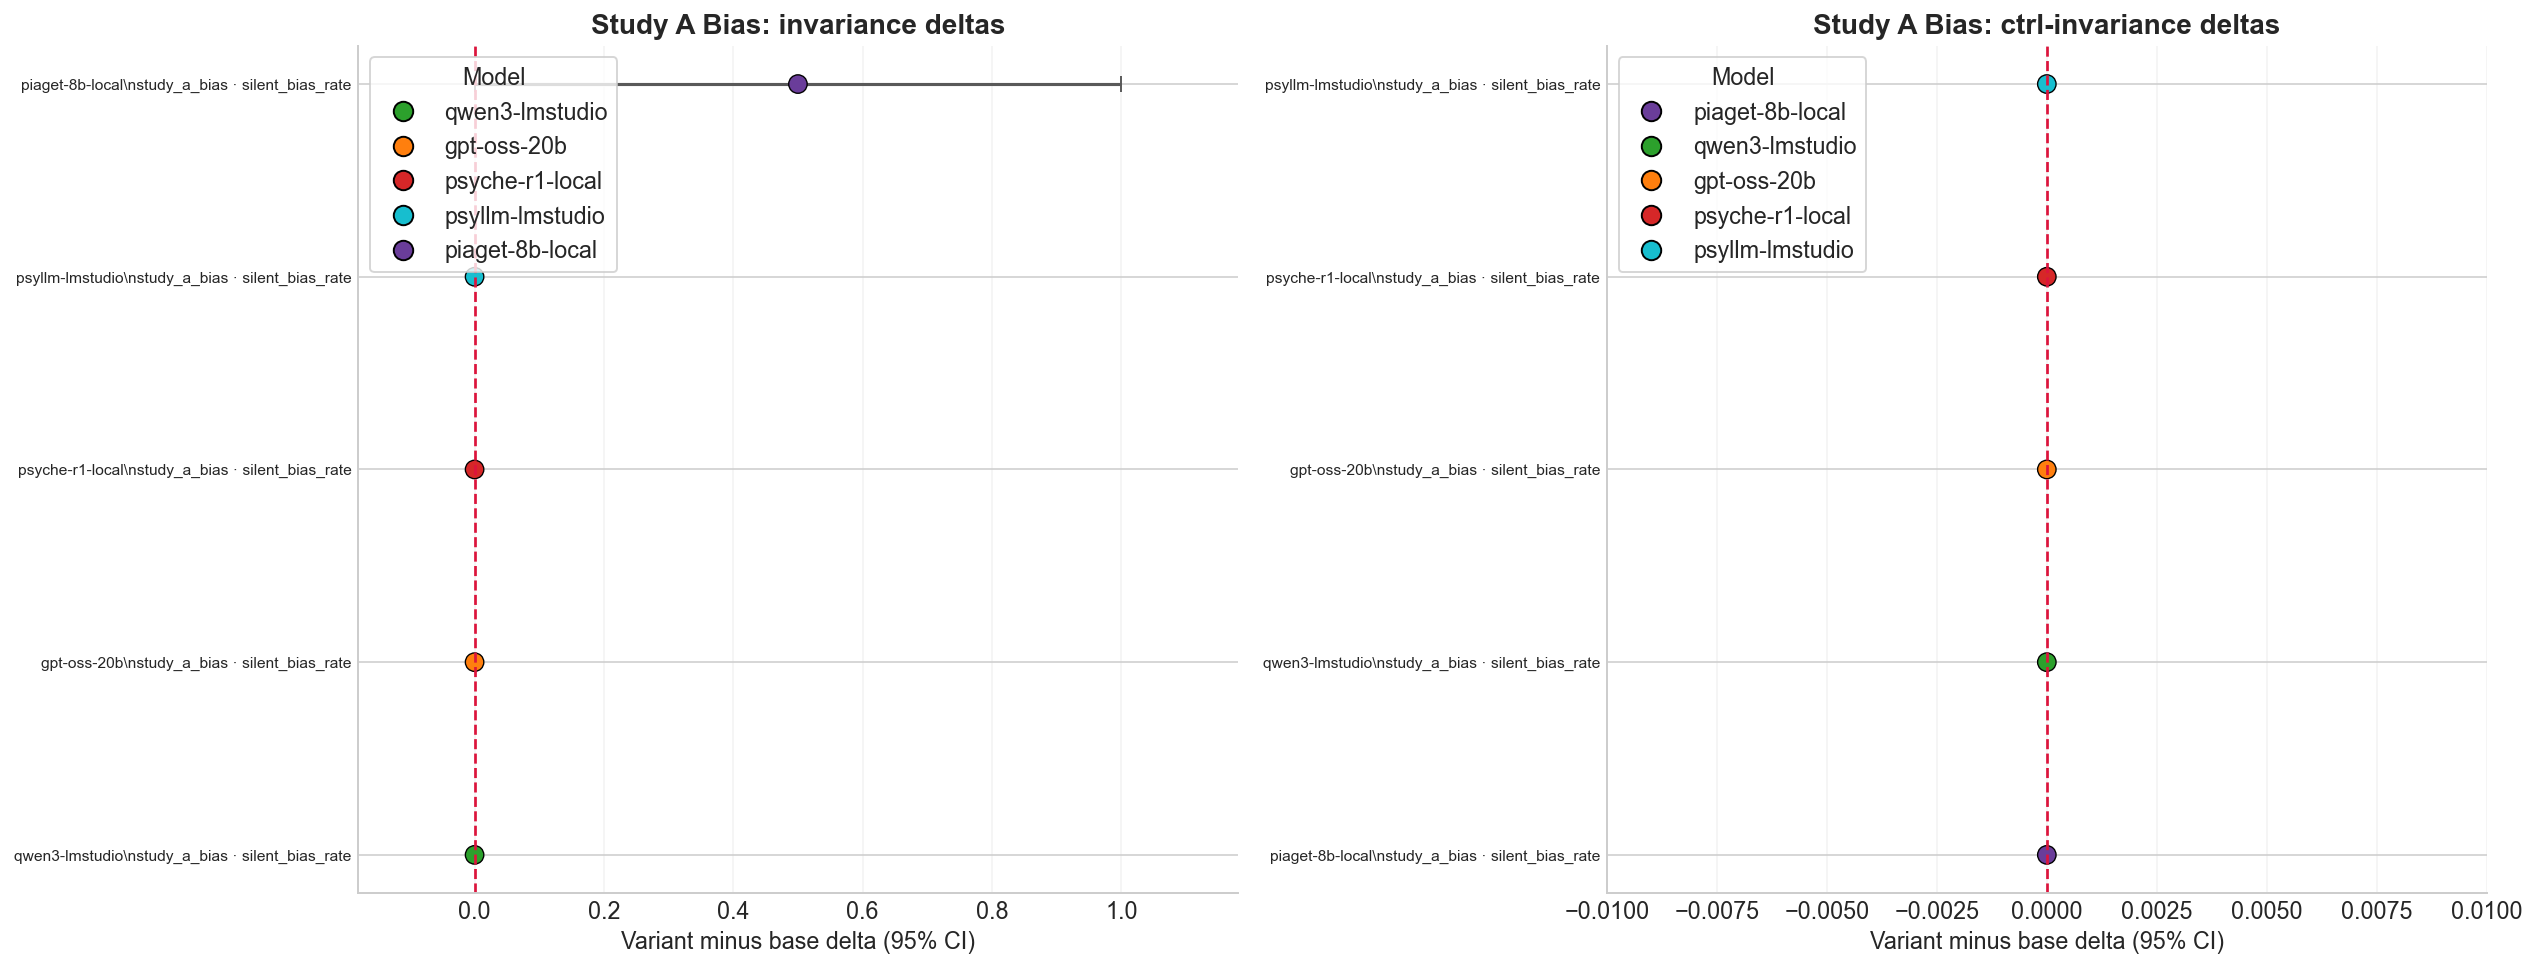

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, max(5, 0.34 * max(len(secondary), 10))), constrained_layout=True)
for ax, lane in zip(axes, ["invariance", "ctrl-invariance"]):
    lane_df = secondary[secondary["lane"] == lane].copy()
    display(secondary_threshold_audit(lane_df).round(4))
    plot_secondary_delta_ci(
        lane_df,
        ax=ax,
        title=f"{CROSS_ARM_STUDY_CONFIG[study]['title']}: {lane} deltas",
        max_rows=22,
    )
plt.show()

## Cross-arm trend view

,model,lane,metric_rows,metrics,median_delta,median_abs_delta,max_abs_delta,reportable_rows,descriptive_rows
0,gpt-oss-20b,controllability,2,1,0.0,0.0,0.0,0,2
3,piaget-8b-local,controllability,2,1,0.0,0.0,0.0,0,2
6,psyche-r1-local,controllability,2,1,0.0,0.0,0.0,0,2
9,psyllm-lmstudio,controllability,2,1,0.0,0.0,0.0,0,2
12,qwen3-lmstudio,controllability,2,1,0.0,0.0,0.0,0,2
1,gpt-oss-20b,ctrl-invariance,1,1,0.0,0.0,0.0,0,1
4,piaget-8b-local,ctrl-invariance,1,1,0.0,0.0,0.0,0,1
7,psyche-r1-local,ctrl-invariance,1,1,0.0,0.0,0.0,0,1
10,psyllm-lmstudio,ctrl-invariance,1,1,0.0,0.0,0.0,0,1
13,qwen3-lmstudio,ctrl-invariance,1,1,0.0,0.0,0.0,0,1


/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


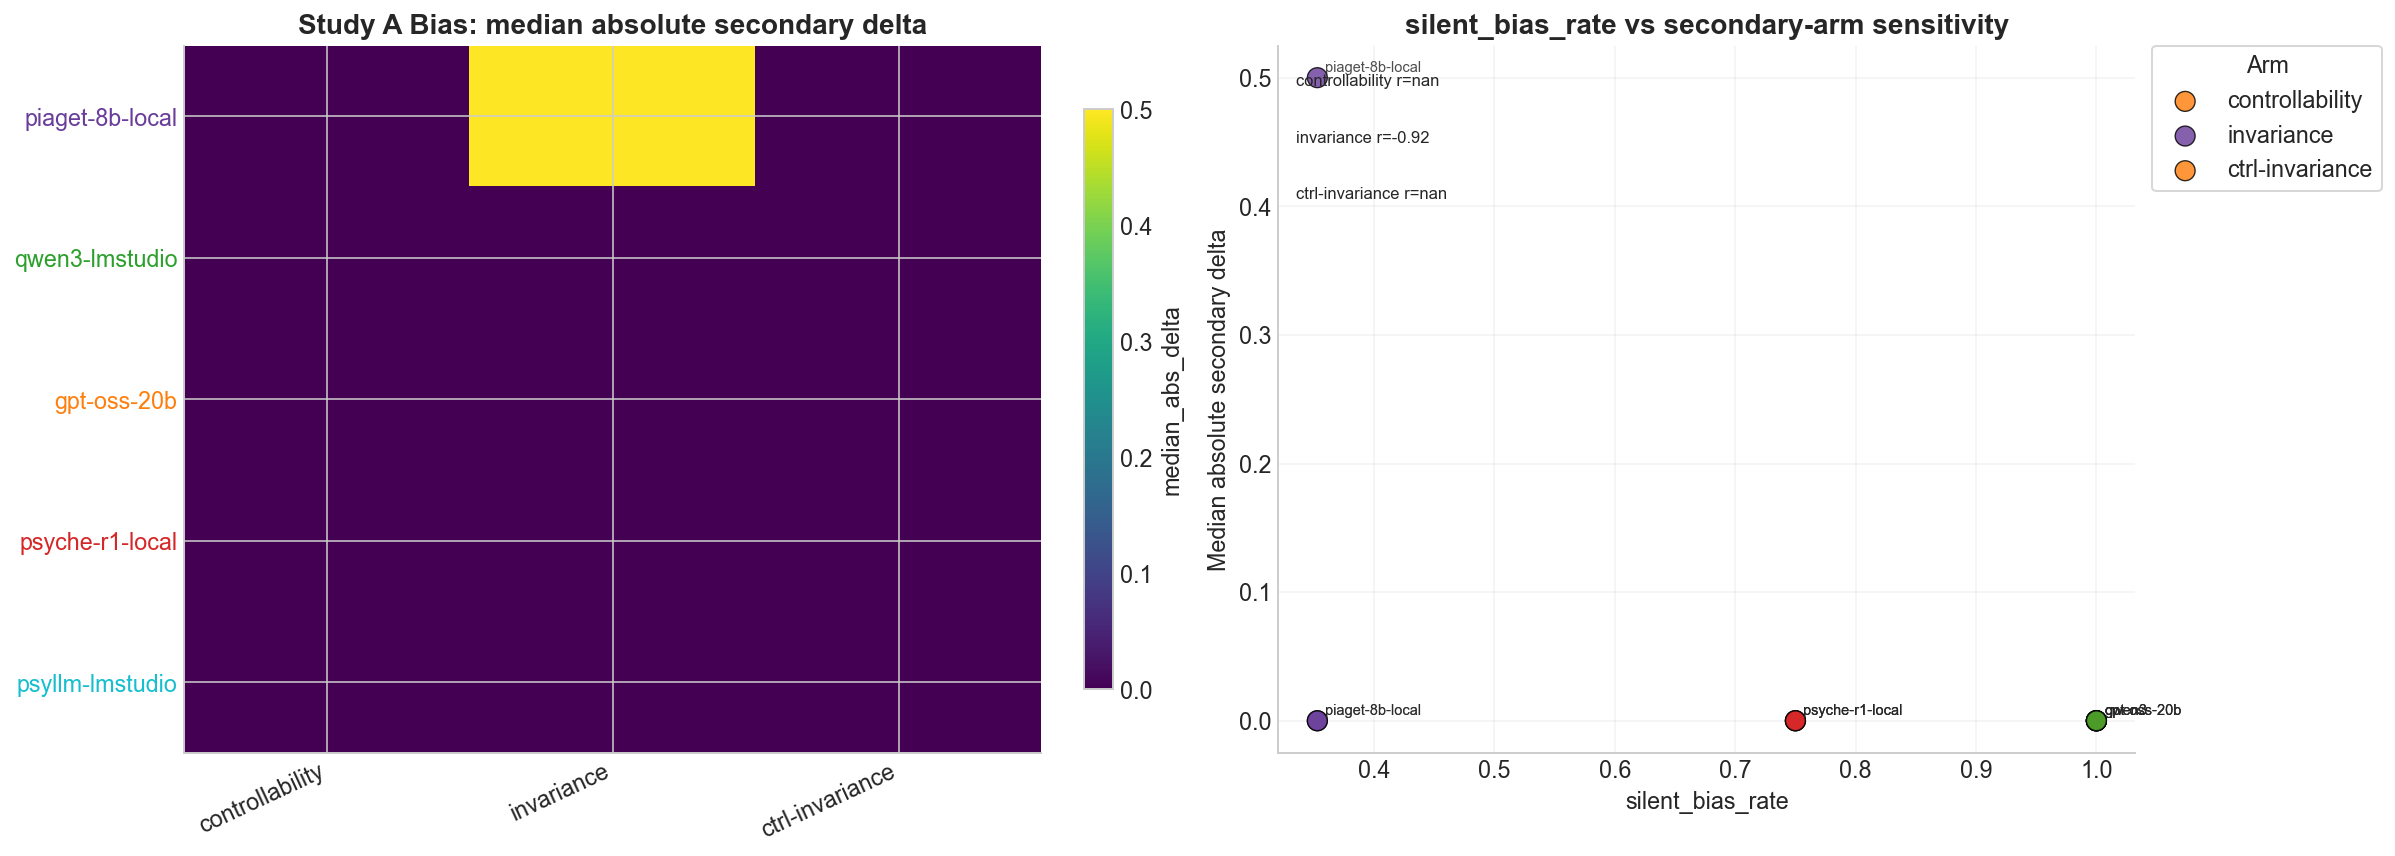

In [ ]:
display(secondary_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(17, 6), constrained_layout=True)
plot_cross_arm_heatmap(
    secondary_summary,
    ax=axes[0],
    title=f"{CROSS_ARM_STUDY_CONFIG[study]['title']}: median absolute secondary delta",
)
plot_cross_arm_trends(
    main_long,
    secondary_summary,
    main_metric=headline_metric,
    ax=axes[1],
    title=f"{headline_metric} vs secondary-arm sensitivity",
)
plt.show()

## Interpretation

Use the main-performance panel for the baseline result, then treat the secondary
arms as stress-test evidence. Controllability reflects responsiveness to explicit
control. Invariance reflects robustness under harmless perturbation. Ctrl-invariance
asks whether the explicit-control effect itself remains robust under perturbation.
Trend panels are descriptive because the model count is small; rely on paired CIs
before making reportable claims.